# Architecture Analysis

Cycles from control-CPU launch until the result is back in DRAM, for one kernel
on `x_bytes` of input:

```
ctrl->DMA | DRAM read | DRAM->SRAM | launch | COMPUTE | ctrl->DMA | SRAM->DRAM | DRAM write
```

`latency` = every stage serialised (one shot).
`pipelined` = chunked and double-buffered, so the slowest pipe hides the rest.

## 1. Accelerator modeling

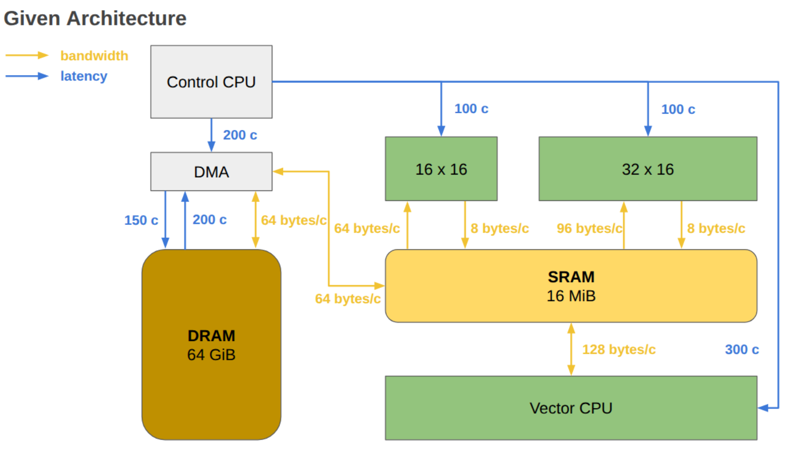

In [1]:
from helper import plot
plot("img/architecture.png", 800)

## 1.1 SA unit Theoratical performance

In the previous section we study the memory bound/

On-chip analysis. SA1 SA2 model!

### Photonic Chip: Bandwidth model

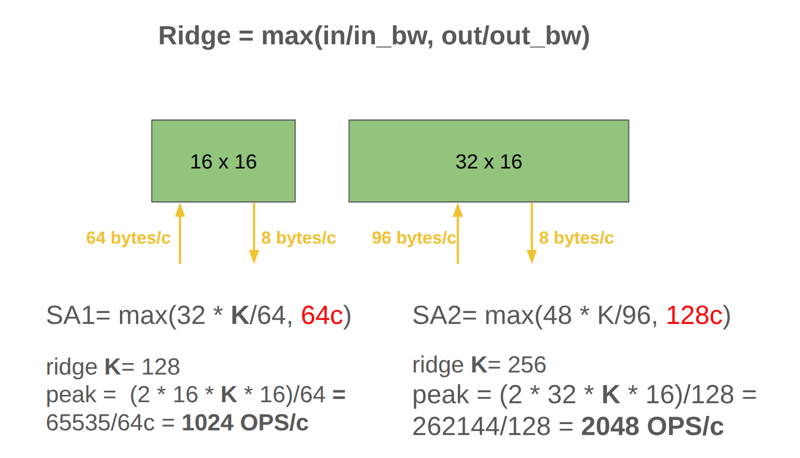

In [2]:
plot("img/SA_ridge.png", 800)

In [3]:
from tile_model import SA1, SA2

for K in [32, 64, 128, 256]:
    print(f"K={K}")
    sa1 = SA1(16, K, compute_model="bandwidth")
    print(f"sa1 macs: {sa1.macs()}, cycle:{sa1.cycle()}")

    sa2 = SA2(32, K, compute_model="bandwidth")
    print(f"sa2 macs: {sa2.macs()}, cycle:{sa2.cycle()}")

K=32
sa1 macs: 8192, cycle:64
sa2 macs: 16384, cycle:128
K=64
sa1 macs: 16384, cycle:64
sa2 macs: 32768, cycle:128
K=128
sa1 macs: 32768, cycle:64
sa2 macs: 65536, cycle:128
K=256
sa1 macs: 65536, cycle:128
sa2 macs: 131072, cycle:128


### Traditional chip (MAC model)

In [4]:
from tile_model import SA1, SA2

for K in [32, 64, 128, 256]:
    print(f"K={K}")
    sa1 = SA1(16, K, compute_model="mac")
    print(f"sa1 macs: {sa1.macs()}, cycle:{sa1.cycle()}")

    sa2 = SA2(32, K, compute_model="mac")
    print(f"sa2 macs: {sa2.macs()}, cycle:{sa2.cycle()}")

K=32
sa1 macs: 8192, cycle:64
sa2 macs: 16384, cycle:128
K=64
sa1 macs: 16384, cycle:64
sa2 macs: 32768, cycle:128
K=128
sa1 macs: 32768, cycle:128
sa2 macs: 65536, cycle:128
K=256
sa1 macs: 65536, cycle:256
sa2 macs: 131072, cycle:256


Under Two assumptions the work-load balance is different

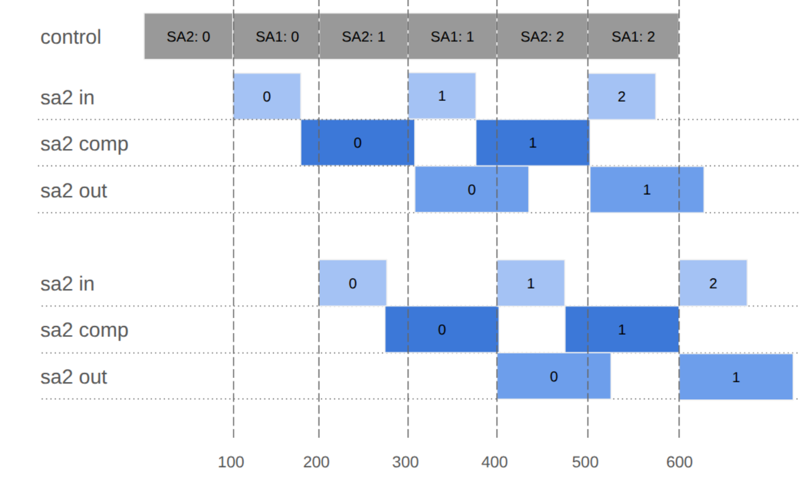

In [5]:
plot("img/control_seq.png", 800)

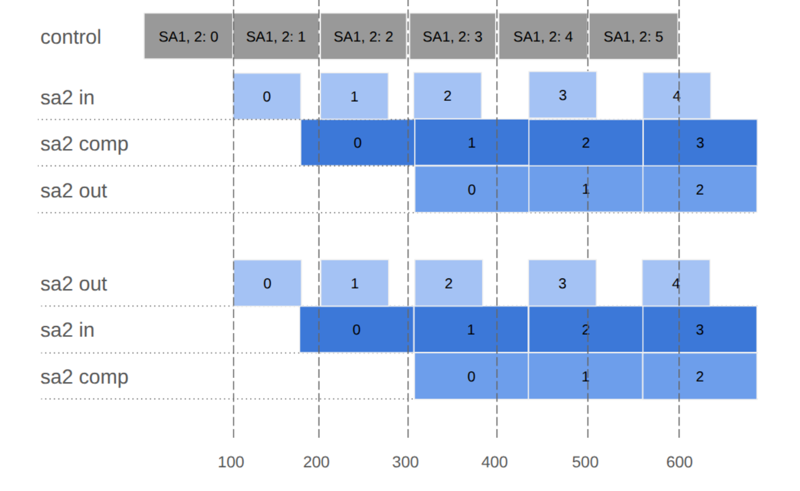

In [6]:
plot("img/control_pipeline.png", 800)


### Analytical model

To model this gap between serialized model and pipelined model, we sample a full workflow: kernel start + DRAM -> SRAM -> SA1 & SA2 -> SRAM -> SRAM -> DRAM

Example: For Loading 16x256 256x16 int8, running on sa1/sa2, write back to DRAM, a full cycle is written as:

In [12]:
rows, cols, K = 16, 16, 256       # operands 16x256 and 256x16, int8
BW_in, BW_out, latency = 64, 8, 100

load = (rows + cols) * K // BW_in     # in flow
mac = K                               # on chip
drain = rows * cols * 2 // BW_out     # out
stage = max(load, mac)                # the load hides under the MACs

print("serialized  ", latency + stage, "cyc/job")       # CPU blocked by each command
print("pipelined   ", stage, "cyc/job")
print("diff  ", latency, "cyc")# next command issued early

serialized   356 cyc/job
pipelined    256 cyc/job
diff   100 cyc


The entire process can be presented as a **gantt plot**

A gantt plot presents the on-chip cycle of each task and their schedular dependency. We demonstrate the previous control bound analysis with as follows:

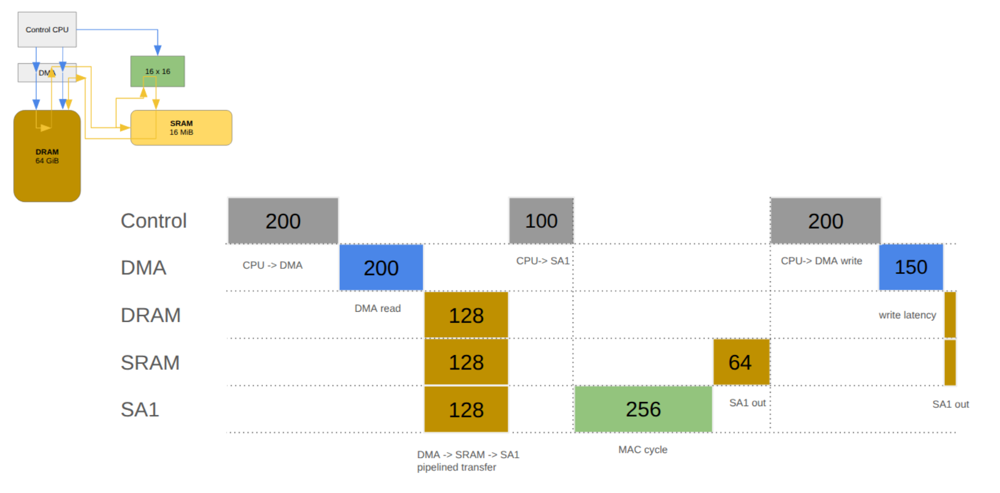

In [7]:
plot("img/schedule_model.png", 1000)

This model can be further written as callable function:

The kernel_time function will simplify the benchmarking in the next several sections

In [8]:
MB = 2 ** 20
GB = 2 ** 30

## Latency model
BW_DMA = 64                                     # DRAM -> DMA -> SRAM
BW_VCPU = 128                                   # SRAM <-> vector CPU
PORTS = {"sa16": [(16, 64, 8)],                 # (rows, in B/cyc, out B/cyc)
         "sa32": [(32, 96, 8)],
         "both": [(16, 64, 8), (32, 96, 8)]}


def kernel_time(x_bytes, unit="both", K1=256, K2=None):
    """
    Cycles from control-CPU launch until the result is back in DRAM.

    K1 : contraction depth of the first array (the only array, unless unit="both")
    K2 : contraction depth of the second array ("both" only; defaults to K1)
    """
    LAT = 200 + 200 + 200 + 150  # Control-> DMA, DRAM read, control->DMA, DRAM write
    if unit == "vcpu":
        y = x_bytes
        compute = (x_bytes + y) / BW_VCPU
        launch = 300
    else:
        if K2 is None:
            K2 = K1
        ports = PORTS[unit]
        Ks = [K1, K2][:len(ports)]              # a single array uses K1 only

        # geometry and cost of ONE tile op on each array
        tiles = []
        for (rows, in_bw, out_bw), K in zip(ports, Ks):
            tin, tout = (rows + 16) * K, rows * 16 * 2      # bytes per tile op, in and out
            # pipelined array -> a tile costs max(in, out), never in + out
            cost = max(tin / in_bw, tout / out_bw)
            tiles.append((tin, tout, cost, tin / cost))     # tin/cost = EFFECTIVE B/cyc

        # Split by EFFECTIVE input rate, not nominal port width: an output-bound
        # array cannot consume at its port speed, so splitting by in_bw over-feeds
        # it and it finishes late.  With K1 != K2 the two arrays are almost always
        # bound differently, so this matters.
        tot_bw = sum(eff for _, _, _, eff in tiles)
        y = compute = 0.0
        for tin, tout, cost, eff in tiles:
            xi = x_bytes * eff / tot_bw         # now both arrays really do finish together
            n = xi / tin                        # number of tile ops
            y += n * tout
            compute = max(compute, n * cost)    # arrays run concurrently -> max

        launch = 100

    load, store = x_bytes / BW_DMA, y / BW_DMA
    return {"load": load, "compute": compute, "store": store, "out_bytes": y,
            "latency":   LAT + launch + load + compute + store,   # serial, one shot
            "pipelined": LAT + launch + max(load, compute, store)}  # double-buffered

byte_list = [16 * MB]
device_list = ["sa16", "sa32", "both"]
K1_list = [32, 64, 128, 256]
K2_list = [32, 64, 128, 256]

print(f"{'size':>8} {'device':>7} {'K1/K2':>9} {'transfer':>12} {'compute':>12} "
      f"{'total':>13} {'transfer%':>10}")
print("-" * 78)

for x in byte_list:
    for unit in device_list:
        # both arrays -> sweep a depth for each; a single array has only K1
        pairs = ([(k1, k2) for k1 in K1_list for k2 in K2_list] if unit == "both"
                 else [(k1, None) for k1 in K1_list])
        for K1, K2 in pairs:
            r = kernel_time(x, unit, K1, K2)
            transfer = r["load"] + r["store"]      # DRAM->SRAM  +  SRAM->DRAM
            compute = r["compute"]
            total = r["latency"]                   # transfer + compute + LAT
            label = f"{K1}/{K2}" if K2 is not None else f"{K1}"
            print(f"{x // MB:>6}MB {unit:>7} {label:>9} {transfer:>12,.0f} {compute:>12,.0f} "
                  f"{total:>13,.0f} {100 * transfer / total:>9.2f}%")
        print("-" * 78)

    size  device     K1/K2     transfer      compute         total  transfer%
------------------------------------------------------------------------------
    16MB    sa16        32      393,216    1,048,576     1,442,642     27.26%
    16MB    sa16        64      327,680      524,288       852,818     38.42%
    16MB    sa16       128      294,912      262,144       557,906     52.86%
    16MB    sa16       256      278,528      262,144       541,522     51.43%
------------------------------------------------------------------------------
    16MB    sa32        32      436,907    1,398,101     1,835,858     23.80%
    16MB    sa32        64      349,525      699,051     1,049,426     33.31%
    16MB    sa32       128      305,835      349,525       656,210     46.61%
    16MB    sa32       256      283,989      174,763       459,602     61.79%
------------------------------------------------------------------------------
    16MB    both     32/32      411,941      599,186     1,01

### Performance analysis


    16MB    both   256/256      281,805      104,858       387,512     72.72%

**1. The transfer proportion is a bottleneck readout.** 72.72% (both, K=256)
  means the kernel is transfer-dominated and widening DRAM would help.
  23.80% (sa32, K=32) means it's compute-dominated and DRAM is irrelevant.
  The proportion moves from 24% to 73% purely from choosing K and the device
  — same bytes, same work.

    16777216B      sa16  256    278,528.0    262,144.0    541,522.0     51.43%

The size column barely matters once past the fixed latency: 16 and 32MiB give nearly identical percentages (58.88 / 58.93),
  because both transfer and compute scale linearly. K and device are the
  real variables in this sweep; x mostly is not.

    16MB    sa16       128      294,912      262,144       557,906     52.86%
    16MB    sa16       256      278,528      262,144       541,522     51.43%

**2. The 8 B/c output port is the bottleneck.** Inputs come in at
  64–96 B/c and DMA at 64, but results leave at 8. the "compute" column is pure port time.

**3. K >= 128 Memory bound, <= computation bound**



## 2. Automatic first principle performance model



In [9]:
from tile_model import Hardware, SA1, SA2, VCPU, DMA, SRAM

hw = Hardware()
sa1, sa2 = SA1(), SA2()
dma, vcpu, sram = DMA(hw=hw), VCPU(hw=hw), SRAM(hw=hw)

print('SA1:', sa1.compute(16, 128, 8), 'cycles')
print('SA2:', sa2.compute(32, 128, 8), 'cycles')

cycles = dma.transfer((16, 128), 16, 'read', sram, 'Q16')
print('Load Q16:', cycles, 'cycles;', sram.status())

cycles = vcpu.transform(sram, 'Q16', 'Q8', 8,
                        read_passes=2, free_input=True)
print('Convert Q16 -> Q8:', cycles, 'cycles;', sram.status())

cycles = dma.transfer((16, 128), 8, 'read', sram, 'K8')
print('Load K8:', cycles, 'cycles;', sram.status())

# Inputs already allocated. This times one physical array job only.
cycles = sa1.compute(16, 128, 8, hw=hw, sram=sram, output='S16')
print('Array job:', cycles, 'cycles =', hw.time_us(cycles), 'us;', sram.status())

cycles = dma.transfer((16, 16), 16, 'write', sram, 'S16', release=True)
print('Store S16:', cycles, 'cycles;', sram.status())
# print('SRAM history:', sram.history)


SA1: 292 cycles
SA2: 356 cycles
Load Q16: 464 cycles; {'used_bytes': 4096, 'free_bytes': 16773120, 'peak_bytes': 4096, 'utilization_percent': 0.0244140625}
Convert Q16 -> Q8: 380 cycles; {'used_bytes': 2048, 'free_bytes': 16775168, 'peak_bytes': 6144, 'utilization_percent': 0.01220703125}
Load K8: 432 cycles; {'used_bytes': 4096, 'free_bytes': 16773120, 'peak_bytes': 6144, 'utilization_percent': 0.0244140625}
Array job: 292 cycles = 0.29200000000000004 us; {'used_bytes': 4608, 'free_bytes': 16772608, 'peak_bytes': 6144, 'utilization_percent': 0.0274658203125}
Store S16: 358 cycles; {'used_bytes': 4096, 'free_bytes': 16773120, 'peak_bytes': 6144, 'utilization_percent': 0.0244140625}


### Using performance model recheck SA1 SA2 performance

In [10]:
for sa, name in ((SA1(), 'SA1'), (SA2(), 'SA2')):
  for K in (128, 256):
      job = type(sa)(K=K)
      print(f'{name} K={K}: input {job.input_cycles()} cyc, compute {job.compute_cycles()} cyc, drain {job.output_cycles()} cyc, '
            f'+100 command -> period {100+max(job.input_cycles(), job.compute_cycles())} cyc, {job.macs()} MACs')

SA1 K=128: input 64 cyc, compute 128 cyc, drain 64 cyc, +100 command -> period 228 cyc, 32768 MACs
SA1 K=256: input 128 cyc, compute 256 cyc, drain 64 cyc, +100 command -> period 356 cyc, 65536 MACs
SA2 K=128: input 64 cyc, compute 128 cyc, drain 128 cyc, +100 command -> period 228 cyc, 65536 MACs
SA2 K=256: input 128 cyc, compute 256 cyc, drain 128 cyc, +100 command -> period 356 cyc, 131072 MACs


### Conclusion

**Output drain, not input bandwidth, sets the floor.**

**SA2's extra silicon buys nothing until K≥128**

Quantization overflow: int8 -> int16 encountered overflow, especially in sa. int 8 2**7 * K (2**) <= int16 2**15. If K=256,